<a href="https://colab.research.google.com/github/CliffAD/CAD-Projects/blob/main/Clifford_Facebook_Analytics_Lab2_Descriptive_Data_Analysis_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
# Descriptive Statistical / Data Analysis of Facebook Friends Dataset

#Author : Clifford Anthony Dsouza
#Date : 21-02-2026.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
# 1) Data Access
# Loading the Datasets into dataframes

df_txt = pd.read_csv("/content/Facebook Friends.txt", sep="\t", encoding="utf-16", engine="python")
df_csv = pd.read_csv("/content/Facebook Friends.csv")
df_xlsx = pd.read_excel("/content/Facebook Friends.xlsx")


In [39]:
# Comparing Shapes and Columns
comparison = pd.DataFrame({
    "TXT Columns": [list(df_txt.columns)],
    "CSV Columns": [list(df_csv.columns)],
    "XLSX Columns": [list(df_xlsx.columns)]
    })
print("TXT shape:", df_txt.shape)
print("CSV shape:", df_csv.shape)
print("XLSX shape:", df_xlsx.shape)

TXT shape: (715, 31)
CSV shape: (715, 3)
XLSX shape: (715, 18)


In [40]:
# 2) Data Examination
df = df_xlsx.copy()
columns = df.columns.tolist()
df = df_xlsx
print("Shape:", df.shape)
print("Columns:", df.columns)
head_rows = df.head()
tail_rows = df.tail()
print(df.head())
print(df.tail())
print(df.dtypes)
print(df.isnull().sum())


Shape: (715, 18)
Columns: Index(['Sample ', 'Age', 'Photos', '# of Tags', 'Albums', 'Gender ', 'Emp',
       'Profile', 'Cover', 'Orientation', 'Relationship', 'Posts', 'Replies',
       'Children', 'Likes', 'Edu', 'Events', 'Friends'],
      dtype='object')
   Sample   Age  Photos  # of Tags  Albums  Gender   Emp  Profile  Cover  \
0        1   57       7         27       5        1    1        1      0   
1        2   42     531        241      19        0    0        0      0   
2        3   42    1396        423      40        0    1        1      0   
3        4   55     394        139      48        0    1        1      1   
4        5   30     916        231      78        1    1        1      1   

   Orientation  Relationship  Posts  Replies  Children  Likes  Edu  Events  \
0            1             1      1        0         3     21    0       0   
1            1             1      5        1         3      9    0       1   
2            1             1    186       31      

In [41]:
# 3) Data Stats (Descriptive Statistics)
desc_stats = df.describe(include="all")
print(desc_stats)


          Sample          Age        Photos     # of Tags      Albums  \
count  715.000000  715.000000    715.000000    715.000000  715.000000   
mean   358.000000   24.406993    723.914685    458.096503   18.952448   
std    206.547008    6.969578   1265.112304    720.835481   22.502860   
min      1.000000   13.000000      0.000000      0.000000    0.000000   
25%    179.500000   21.000000    124.500000     75.500000    6.000000   
50%    358.000000   22.000000    320.000000    250.000000   12.000000   
75%    536.500000   25.000000    757.000000    566.500000   22.500000   
max    715.000000   81.000000  11995.000000  10460.000000  172.000000   

          Gender          Emp     Profile       Cover  Orientation  \
count  715.000000  715.000000  715.000000  715.000000   715.000000   
mean     0.541259    0.745455    0.917483    0.507692     0.956643   
std      0.517932    0.435910    0.275344    0.500291     0.203801   
min      0.000000    0.000000    0.000000    0.000000     0.00

In [42]:
desc_stats.to_html("Clifford_Facebook_Descriptive_Statistics.html")

<Figure size 1200x600 with 0 Axes>

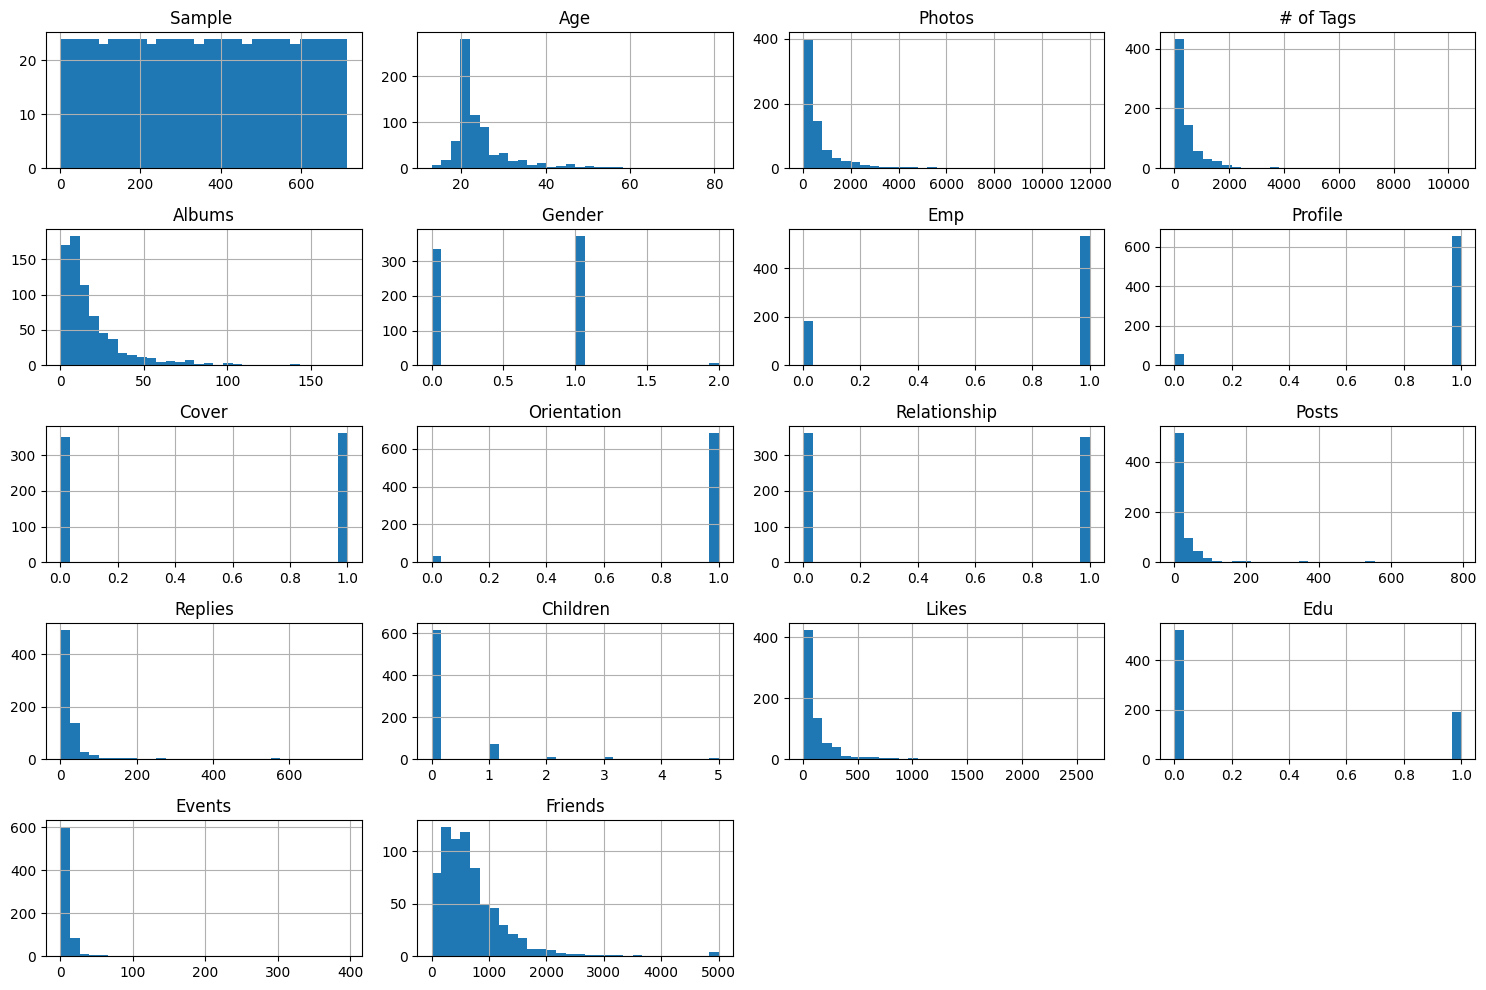

In [43]:
# 4) Data Visualization of Facebook Analytics
# Histograms for numerical columns

num_cols = ["Age", "Gender ", "Photos", "# of Tags", "Albums", "Posts", "Replies", "Likes", "Friends"]

plt.figure(figsize=(12, 6))
df.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.savefig("histograms.png")

for col in num_cols:
  plt.figure(figsize=(8, 5))
  sns.histplot(df[col], bins=30, kde=True)
  plt.title(f"Histogram of {col.strip()}")
  plt.xlabel(col.strip())
  plt.ylabel("Frequency")
  plt.savefig(f"histogram_{col.strip()}.png")
  plt.close()

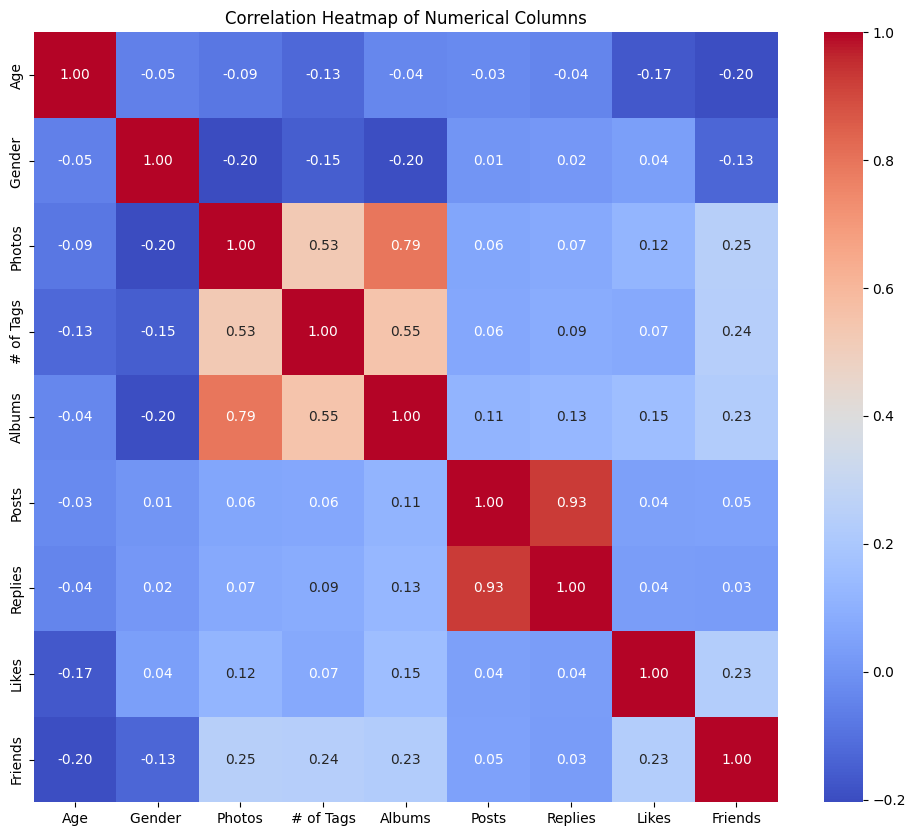

In [44]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Columns')
plt.savefig('correlation_heatmap.png')
plt.show()
plt.close()

In [45]:
#Frequency plot for categorical / binary data
binary_cols = [col for col in df.columns if df[col].nunique() <= 2]

for i, col in enumerate(binary_cols[:6], 1):
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df[col])
    plt.xlabel(col.strip())
    plt.ylabel("Count")
    plt.title(f"Frequency of {col.strip()}")
    plt.tight_layout()
    plt.savefig(f"frequency_{col.strip()}.png")
    plt.close()

In [46]:
with open("facebook_analysis.html", "w", encoding="utf-8") as f:
    f.write("<h1>Facebook Friends Dataset Analysis</h1>")
    f.write("<h2>1. Data Access Comparison</h2>")
    f.write(comparison.to_html())
    f.write("<h2>2. Data Examination</h2>")
    f.write("<h3>Column Names</h3>")
    f.write(str(columns))
    f.write("<h3>Head Rows</h3>")
    f.write(head_rows.to_html())
    f.write("<h3>Tail Rows</h3>")
    f.write(tail_rows.to_html())
    # Define dtypes and missing here as they were not defined globally
    dtypes = df.dtypes
    missing = df.isnull().sum()
    f.write("<h3>Data Types</h3>")
    f.write(dtypes.to_frame().to_html())
    f.write("<h3>Missing Values</h3>")
    f.write(missing.to_frame().to_html())
    f.write("<h2>3. Descriptive Statistics</h2>")
    f.write(desc_stats.to_html())
    f.write("<h2>4. Data Visualization</h2>")
    f.write("<p><img src='histograms.png' width='600'></p>")
    f.write("<p><img src='correlation_heatmap.png' width='600'></p>") # Adding the heatmap
    # Removed <p><img src='frequency.png' width='600'></p> as individual frequency plots are saved.
    print("Analysis complete.\nResults saved to facebook_analysis.html")

Analysis complete.
Results saved to facebook_analysis.html


In [47]:
# End of Program LAB-2 Assignment Descriptive Data Analysis / EDA